In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import create_params
from lmfit import minimize
from lmfit import Parameters

In [17]:
from header import *

print("\nCalibrating:")


#group the data
signal,data=load("Data\Zeeman Data\data_z5\\")


GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

grouped_data=group(data, N_GROUPS, GROUP_SIZE)

#truncate the calibration data
i=18000
f=75000
truncated_grouped_data=grouped_data[:,i//GROUP_SIZE:f//GROUP_SIZE]

data=unp.nominal_values(truncated_grouped_data)
uncertainty=unp.std_devs(truncated_grouped_data)
t=np.linspace(0,1,len(grouped_data[0]))
x=np.linspace(0,1,len(grouped_data[0]))[i//GROUP_SIZE:f//GROUP_SIZE]

<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\Student\AppData\Local\Temp\ipykernel_9980\2280235122.py:7: SyntaxWarning: invalid escape sequence '\Z'
  signal,data=load("Data\Zeeman Data\data_z5\\")



Calibrating:
Loading Files
Grouping Data


<ErrorbarContainer object of 3 artists>

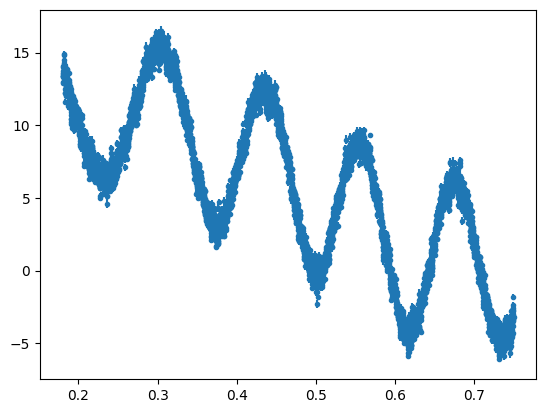

In [19]:
plt.errorbar(x,data[0],yerr=uncertainty[0],linestyle='',marker='.')

In [4]:
def model(params,x,order):
    A=0.
    phi=0.
    C=0.
    for o in range(order[0]+1):
        A+=params[f'A{o}']*x**o
    for o in range(order[1]+1):
        phi+=params[f'phi{o}']*x**o
    for o in range(order[2]+1):
        C+=params[f'C{o}']*x**o

    return A*np.cos(phi)+C

def residual(params, x, data, uncertainty, model):

    modelv = model(params,x)

    return (data-modelv) / uncertainty

linear = lambda params,x: model(params=params,x=x,order=(1,1,1))
quadratic = lambda params,x: model(params=params,x=x,order=(2,2,2))
cubic = lambda params,x: model(params=params,x=x,order=(3,3,3))

def quartic(params,x):

    A0=params['A0']
    A1=params['A1']
    A2=params['A2']
    A3=params['A3']
    A4=params['A4']

    phi0=params['phi0']
    phi1=params['phi1']
    phi2=params['phi2']
    phi3=params['phi3']
    phi4=params['phi4']

    C0=params['C0']
    C1=params['C1']
    C2=params['C2']
    C3=params['C3']
    C4=params['C4']

    if phi4==0:
        return 10000

    return (A0 + A1*x + A2*x**2 + A3*x**3 +A4*x**4) * np.cos((phi0 + phi1*x + phi2*x**2 + phi3*x**3 +phi4*x**4)) + (C0 + C1*x + C2*x**2 + C3*x**3 +C4*x**4)



In [5]:
params = create_params(A0=5, A1=0, A2=0, A3=0, A4=0,phi0=1, phi1 =23.4, phi2=0, phi3=0, phi4=0, C0 = 10, C1=-7, C2=0, C3=0,C4=0)

In [6]:
def heat(params):
    hot_params=(params).copy()
    dict=params.valuesdict()
    for name,ovalue in dict.items():
        hot_params[name].set(value=ovalue*np.random.normal(1,0.02))
    
    return hot_params

In [7]:
p1=params.copy()
p1['A2'].set(vary=False)
p1['A3'].set(vary=False)
p1['A4'].set(vary=False)
p1['phi2'].set(vary=False)
p1['phi3'].set(vary=False)
p1['phi4'].set(vary=False)
p1['C2'].set(vary=False)
p1['C3'].set(vary=False)
p1['C4'].set(vary=False)
out1 = minimize(residual, p1, args=(x, data, uncertainty, linear))

In [8]:
p2=heat(out1.params)
p2['A2'].set(vary=True)
p2['phi2'].set(vary=True)
p2['C2'].set(vary=True)
out2 = minimize(residual, p2, args=(x, data, uncertainty, quadratic))

In [9]:
p3=heat(out2.params)
p3['A3'].set(vary=True)
p3['phi3'].set(vary=True)
p3['C3'].set(vary=True)
out3 = minimize(residual, p3, args=(x, data, uncertainty, cubic))

In [10]:
p4=heat(out3.params)
p4['A4'].set(vary=True)
p4['phi4'].set(vary=True)
p4['C4'].set(vary=True)
out4 = minimize(residual, p4, args=(x, data, uncertainty, quartic))


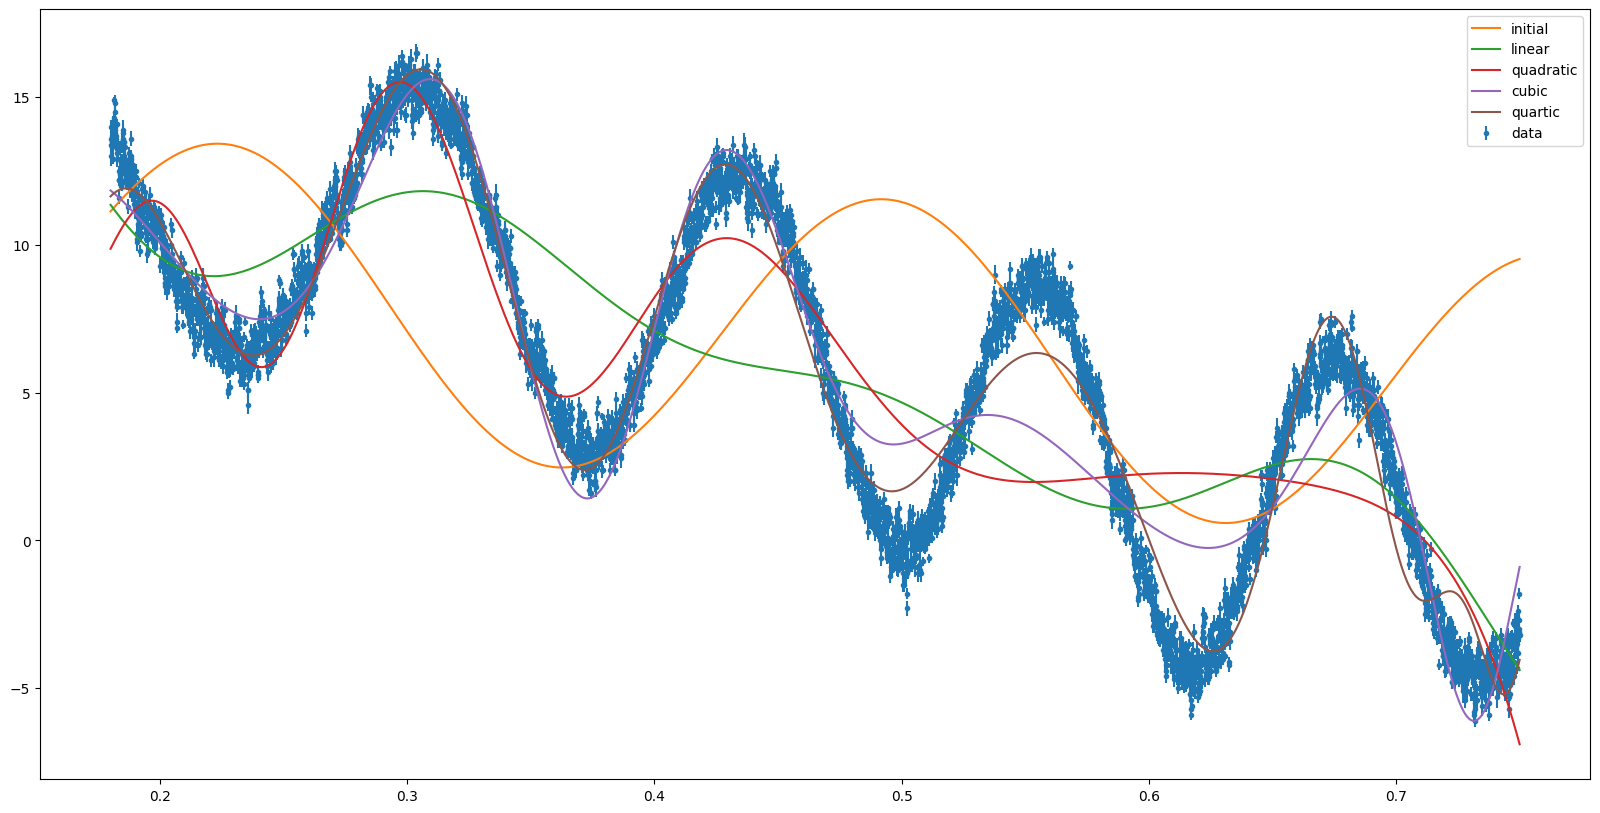

In [11]:
plt.figure(figsize=(20,10))
plt.errorbar(x,data,yerr=uncertainty,linestyle='',marker='.',zorder=0,label='data')
plt.plot(x,linear(params,x),label='initial')
plt.plot(x,linear(out1.params,x),label='linear')
plt.plot(x,quadratic(out2.params,x),label='quadratic')
plt.plot(x,cubic(out3.params,x),label='cubic')
plt.plot(x,quartic(out4.params,x),label='quartic')
plt.legend()

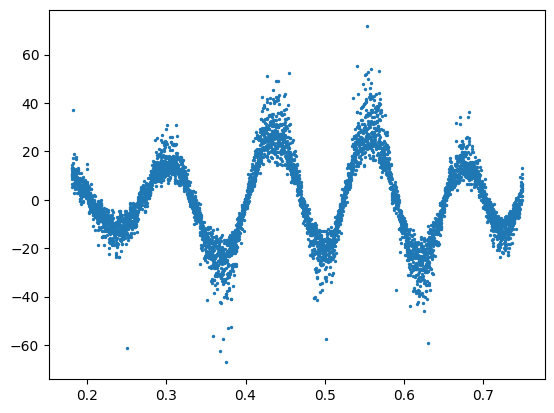

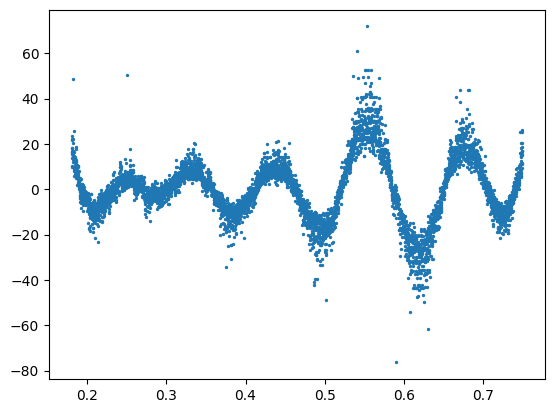

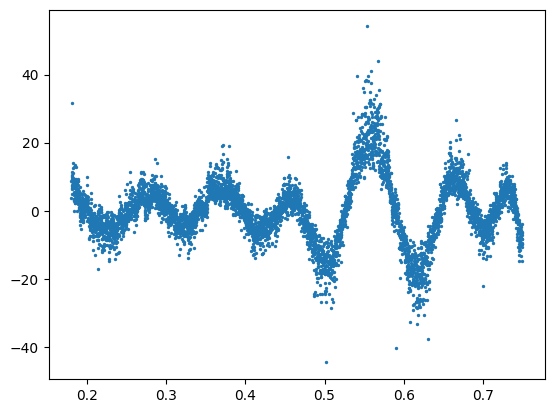

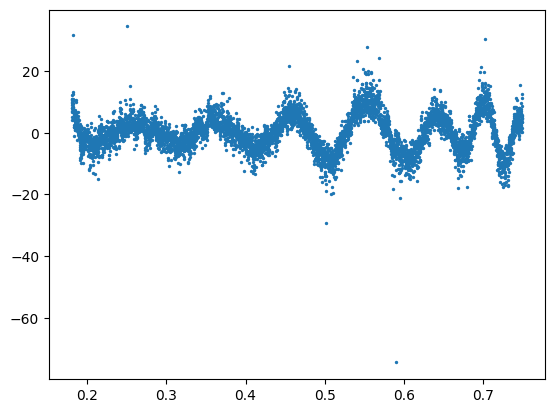

In [12]:
plt.scatter(x,residual(out1.params,x,data,uncertainty,linear),s=2)
plt.show()
plt.scatter(x,residual(out2.params,x,data,uncertainty,quadratic),s=2)
plt.show()
plt.scatter(x,residual(out3.params,x,data,uncertainty,cubic),s=2)
plt.show()
plt.scatter(x,residual(out4.params,x,data,uncertainty,quartic),s=2)
plt.show()

In [13]:
out4.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
A0      -223.6     -inf      inf    24.32     True     None     None
A1        2492     -inf      inf    191.9     True     None     None
A2       -8681     -inf      inf    554.5     True     None     None
A3    1.186e+04     -inf      inf    693.7     True     None     None
A4       -5578     -inf      inf    317.4     True     None     None
C0       160.1     -inf      inf    25.36     True     None     None
C1       -1712     -inf      inf    198.9     True     None     None
C2        6162     -inf      inf    569.9     True     None     None
C3       -8804     -inf      inf    705.8     True     None     None
C4        4326     -inf      inf    319.2     True     None     None
phi0     25.28     -inf      inf   0.8975     True     None     None
phi1    -197.2     -inf      inf    7.016     True     None     None
phi2     591.7     -inf      inf    19.71     True     None     None
phi3    -493.9     -inf      in

In [14]:

GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

grouped_signal=group(signal, N_GROUPS, GROUP_SIZE)

#truncate the calibration data
i=18000
f=75000
truncated_grouped_signal=grouped_signal[:,i//GROUP_SIZE:f//GROUP_SIZE]

v=unp.nominal_values(grouped_signal)


Grouping Data


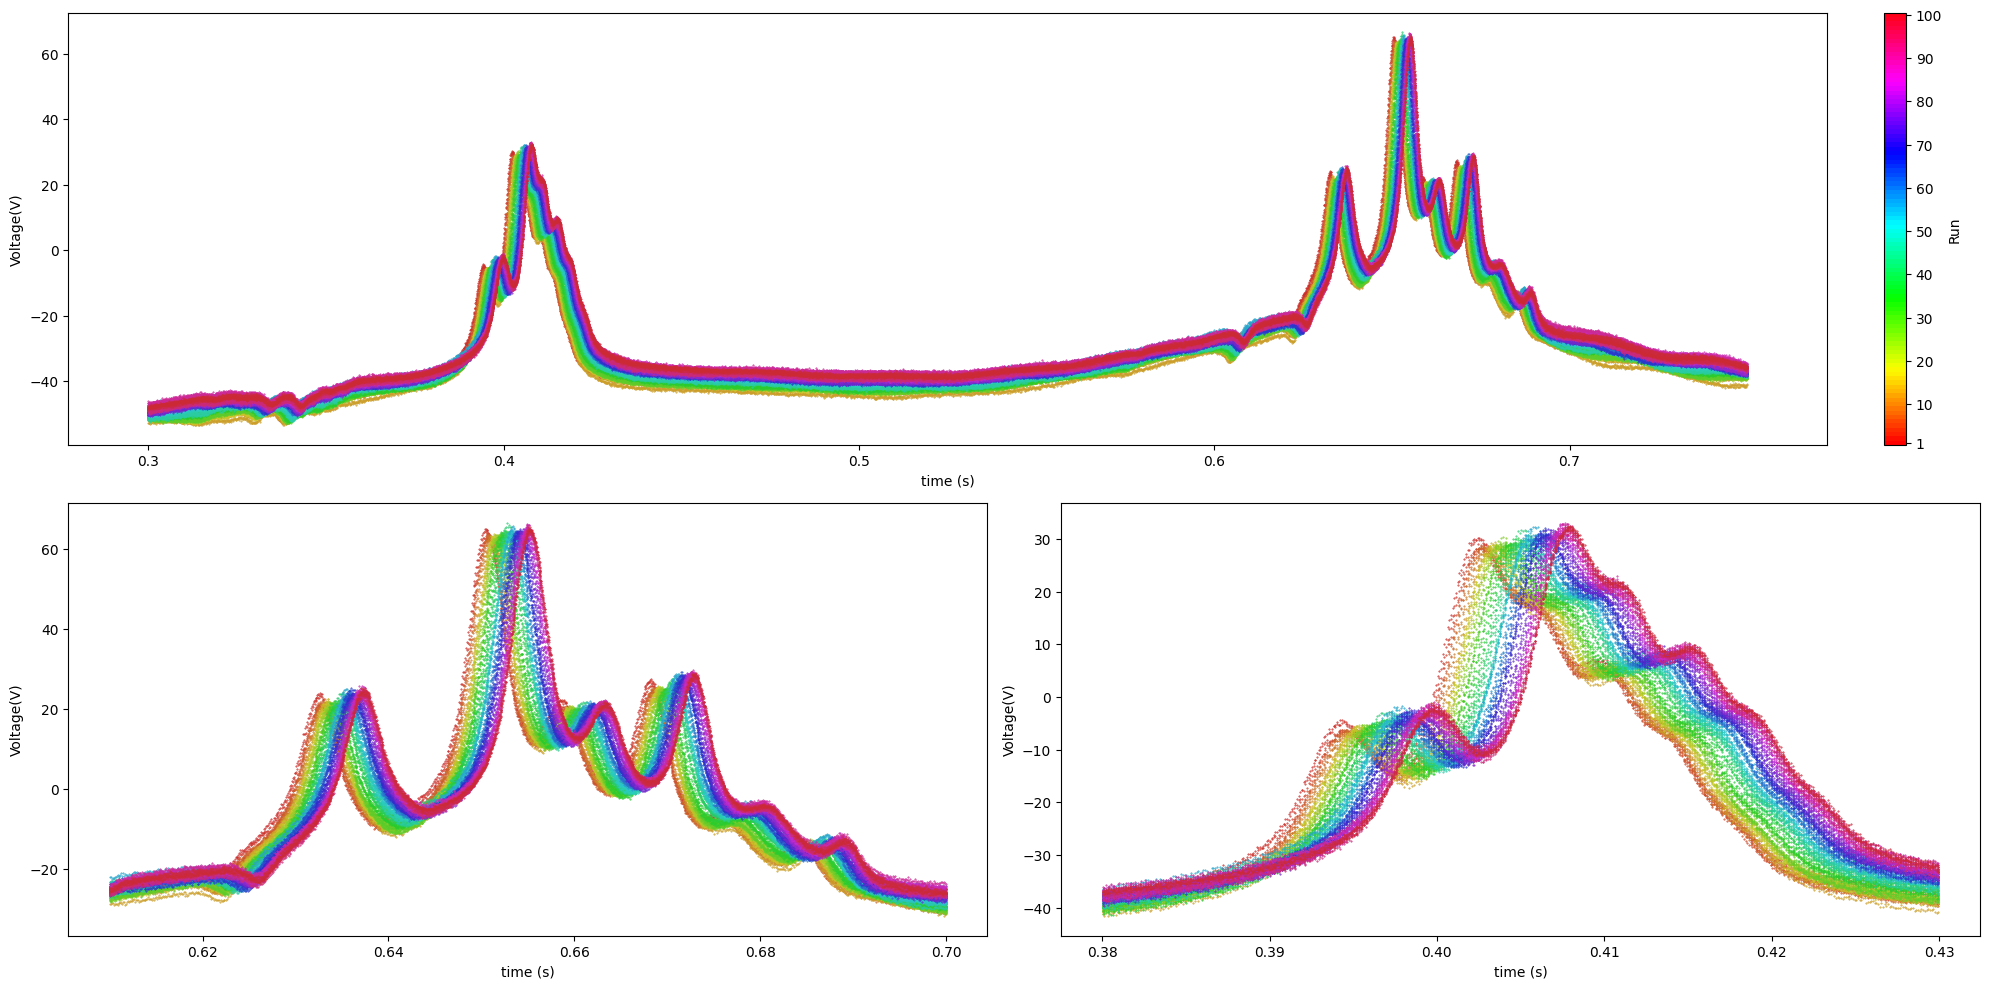

In [16]:
fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(100):
    spec=v[i,3000:7500]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(t[3000:7500],spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,6100:7000]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,0].scatter(t[6100:7000],spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,3800:4300]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,1].scatter(t[3800:4300],spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()




In [ ]:
fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(100):
    spec=v[i,3000:7500]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(t[3000:7500],spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,6100:7000]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,0].scatter(t[6100:7000],spec,s=0.2,color=col)

for i in range(100):
    spec=v[i,3800:4300]
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,1].scatter(t[3800:4300],spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()


In [ ]:
import winsound
frequency = 2300  # Set Frequency To 2500 Hertz
duration = 2000  # Set Duration To 1000 ms == 1 second
winsound.Beep(frequency, duration)